# LSTM - PM2.5 Forecasting (Multi-Output 7 Days)

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
import copy

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [158]:
# === CONFIG ===
WINDOW_SIZE = 21     
FORECAST_DAYS = 7    # พยากรณ์ 7 วันล่วงหน้า
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Load dataset
data = pd.read_csv('../data/dataset/dataset.csv', parse_dates=['date'])
data = data.sort_values(['station', 'date']).reset_index(drop=True)

# Feature columns (ทุกอย่างยกเว้น date, station)
feature_cols = [c for c in data.columns if c not in ['date', 'station']]
target_col = 'pm25'

print(f"Loaded: {data.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Stations: {data['station'].unique()}")
data.head()

Loaded: (18270, 13)
Features (11): ['dew_point_2m_mean', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean', 'pm25', 'wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos']
Stations: ['05T' '42T' '57T' '58T' '62T' '79T' '82T' '83T' '86T' '87T']


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,wind_dir_cos,month_sin,month_cos
0,2021-01-01,12.8,22.1,0.0,9.5,1014.3,56,20.0,05T,0.754710,0.656059,0.5,0.866025
1,2021-01-02,14.9,22.1,0.0,6.5,1013.5,64,25.0,05T,0.173648,0.984808,0.5,0.866025
2,2021-01-03,16.2,23.5,0.0,7.8,1012.1,65,37.0,05T,0.292372,0.956305,0.5,0.866025
3,2021-01-04,17.8,25.0,0.0,7.6,1011.8,65,31.0,05T,0.406737,0.913545,0.5,0.866025
4,2021-01-05,19.3,25.5,0.0,5.9,1011.8,69,31.0,05T,0.358368,0.933580,0.5,0.866025


In [159]:
# === Normalize (แยก scaler ตามลักษณะการกระจายตัว) ===
# RobustScaler: ทนต่อ outlier → ใช้กับ pm25 (เบ้ขวา, max 374) และ precipitation (เบ้, ส่วนใหญ่ 0)
# StandardScaler: กระจายค่อนข้างปกติ → weather features อื่นๆ
# Passthrough: ไม่ scale → sin/cos features (อยู่ใน [-1, 1] อยู่แล้ว)

robust_cols = ['pm25', 'precipitation_sum']
standard_cols = ['dew_point_2m_mean', 'temperature_2m_mean', 'wind_speed_10m_mean',
                 'surface_pressure_mean', 'relative_humidity_2m_mean']
passthrough_cols = ['wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos']

# Fit บน training period เท่านั้น (2021-2023)
train_mask = data['date'] < '2024-01-01'

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()
robust_scaler.fit(data.loc[train_mask, robust_cols])
standard_scaler.fit(data.loc[train_mask, standard_cols])

# Transform ทุก period (passthrough_cols ไม่ต้อง transform)
data_scaled = data.copy()
data_scaled[robust_cols] = robust_scaler.transform(data[robust_cols])
data_scaled[standard_cols] = standard_scaler.transform(data[standard_cols])

# บันทึก index ของ pm25 ใน feature_cols สำหรับ inverse transform
pm25_idx = feature_cols.index(target_col)
pm25_robust_idx = robust_cols.index(target_col)

print(f"PM2.5 index in features: {pm25_idx}")
print(f"PM2.5 RobustScaler — median: {robust_scaler.center_[pm25_robust_idx]:.2f}, IQR: {robust_scaler.scale_[pm25_robust_idx]:.2f}")
print(f"\nScaler groups:")
print(f"  RobustScaler:   {robust_cols}")
print(f"  StandardScaler: {standard_cols}")
print(f"  Passthrough:    {passthrough_cols}")
data_scaled.head()

PM2.5 index in features: 6
PM2.5 RobustScaler — median: 15.00, IQR: 16.00

Scaler groups:
  RobustScaler:   ['pm25', 'precipitation_sum']
  StandardScaler: ['dew_point_2m_mean', 'temperature_2m_mean', 'wind_speed_10m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean']
  Passthrough:    ['wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos']


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,wind_dir_cos,month_sin,month_cos
0,2021-01-01,-2.494665,-1.939111,-0.204545,0.527001,1.203297,-1.803808,0.3125,05T,0.754710,0.656059,0.5,0.866025
1,2021-01-02,-1.908403,-1.939111,-0.204545,-0.295773,1.146871,-1.117586,0.6250,05T,0.173648,0.984808,0.5,0.866025
2,2021-01-03,-1.545479,-1.331653,-0.204545,0.060762,1.048126,-1.031808,1.3750,05T,0.292372,0.956305,0.5,0.866025
3,2021-01-04,-1.098803,-0.680805,-0.204545,0.005911,1.026967,-1.031808,1.0000,05T,0.406737,0.913545,0.5,0.866025
4,2021-01-05,-0.680045,-0.463856,-0.204545,-0.460328,1.026967,-0.688696,1.0000,05T,0.358368,0.933580,0.5,0.866025


In [160]:
# === Create Sequences (Sliding Window) ===
# X: [window_size, num_features]  ข้อมูลวันที่ 1-7
# Y: [forecast_days]             PM2.5 วันที่ 8-14

def create_sequences(df, stations, feature_cols, target_col, window_size, forecast_days):
    """สร้าง sequences แยกแต่ละสถานี ไม่ให้ข้อมูลข้ามสถานี"""
    X_list, y_list, meta_list = [], [], []
    
    for station in stations:
        st_data = df[df['station'] == station].sort_values('date').reset_index(drop=True)
        features = st_data[feature_cols].values
        target = st_data[target_col].values
        dates = st_data['date'].values
        
        for i in range(len(st_data) - window_size - forecast_days + 1):
            X_list.append(features[i:i + window_size])                    # shape: (window, n_features)
            y_list.append(target[i + window_size:i + window_size + forecast_days])  # shape: (forecast_days,)
            meta_list.append({
                'station': station,
                'input_start': dates[i],
                'input_end': dates[i + window_size - 1],
                'target_start': dates[i + window_size],
                'target_end': dates[i + window_size + forecast_days - 1],
            })
    
    return np.array(X_list), np.array(y_list), pd.DataFrame(meta_list)

stations = data['station'].unique()
X_all, y_all, meta_all = create_sequences(
    data_scaled, stations, feature_cols, target_col, WINDOW_SIZE, FORECAST_DAYS
)
print(f"X: {X_all.shape}  (samples, window, features)")
print(f"y: {y_all.shape}  (samples, forecast_days)")

X: (18000, 21, 11)  (samples, window, features)
y: (18000, 7)  (samples, forecast_days)


In [161]:
# === Time-based Train / Validation / Test Split ===
# Train: target ก่อน 2024 | Val: target ปี 2024 | Test: target ปี 2025

train_idx = meta_all['target_end'] < '2024-01-01'
val_idx   = (meta_all['target_start'] >= '2024-01-01') & (meta_all['target_end'] < '2025-01-01')
test_idx  = meta_all['target_start'] >= '2025-01-01'

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]
meta_test = meta_all[test_idx].reset_index(drop=True)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 10690 samples
Val:   3600 samples
Test:  3590 samples


In [162]:
# === Dataset & DataLoader ===
class PM25Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# === LSTM Model ===
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, forecast_days):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, forecast_days)
    
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.dropout(h_n[-1])
        return self.fc(out)

input_size = len(feature_cols)
print(f"Model input_size: {input_size}")

Model input_size: 11


In [163]:
# === Training Function (with LR Scheduler, Gradient Clipping & Weight Decay) ===
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4, patience=30):
    """Train with early stopping, ReduceLROnPlateau, gradient clipping, and L2 regularization."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_state = None
    wait = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        train_losses.append(epoch_loss / len(train_loader.dataset))
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        # LR Scheduler step
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break
        
        # Log every 10 epochs
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.2e}")

    print(f"\nBest val loss: {best_val_loss:.6f} at epoch {len(train_losses) - wait}")
    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [164]:
# === Hyperparameters ===
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.2
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-4
EPOCHS = 150
PATIENCE = 15

print("Hyperparameters:")
print(f"  hidden_size:  {HIDDEN_SIZE}")
print(f"  num_layers:   {NUM_LAYERS}")
print(f"  dropout:      {DROPOUT}")
print(f"  lr:           {LEARNING_RATE} (ReduceLROnPlateau)")
print(f"  batch_size:   {BATCH_SIZE}")
print(f"  weight_decay: {WEIGHT_DECAY}")
print(f"  grad_clip:    1.0")
print(f"  epochs:       {EPOCHS} (early stopping patience={PATIENCE})")

Hyperparameters:
  hidden_size:  32
  num_layers:   1
  dropout:      0.2
  lr:           0.001 (ReduceLROnPlateau)
  batch_size:   32
  weight_decay: 0.0001
  grad_clip:    1.0
  epochs:       150 (early stopping patience=15)


Epoch   1 | Train: 1.222322 | Val: 0.594080 | LR: 1.00e-03
Epoch   2 | Train: 0.831888 | Val: 0.566104 | LR: 1.00e-03
Epoch   3 | Train: 0.754323 | Val: 0.572388 | LR: 1.00e-03
Epoch   4 | Train: 0.713762 | Val: 0.587854 | LR: 1.00e-03
Epoch   5 | Train: 0.681796 | Val: 0.578140 | LR: 1.00e-03
Epoch   6 | Train: 0.639362 | Val: 0.592256 | LR: 1.00e-03
Epoch   7 | Train: 0.635018 | Val: 0.572234 | LR: 1.00e-03
Epoch   8 | Train: 0.594183 | Val: 0.556529 | LR: 1.00e-03
Epoch   9 | Train: 0.564054 | Val: 0.621943 | LR: 1.00e-03
Epoch  10 | Train: 0.552405 | Val: 0.594396 | LR: 1.00e-03
Epoch  11 | Train: 0.553304 | Val: 0.687155 | LR: 1.00e-03
Epoch  12 | Train: 0.530135 | Val: 0.666134 | LR: 1.00e-03
Epoch  13 | Train: 0.512840 | Val: 0.661828 | LR: 1.00e-03
Epoch  14 | Train: 0.494682 | Val: 0.664865 | LR: 1.00e-03
Epoch  15 | Train: 0.484057 | Val: 0.734967 | LR: 1.00e-03
Epoch  16 | Train: 0.478104 | Val: 0.603101 | LR: 1.00e-03
Epoch  17 | Train: 0.465772 | Val: 0.694035 | LR: 1.00e-

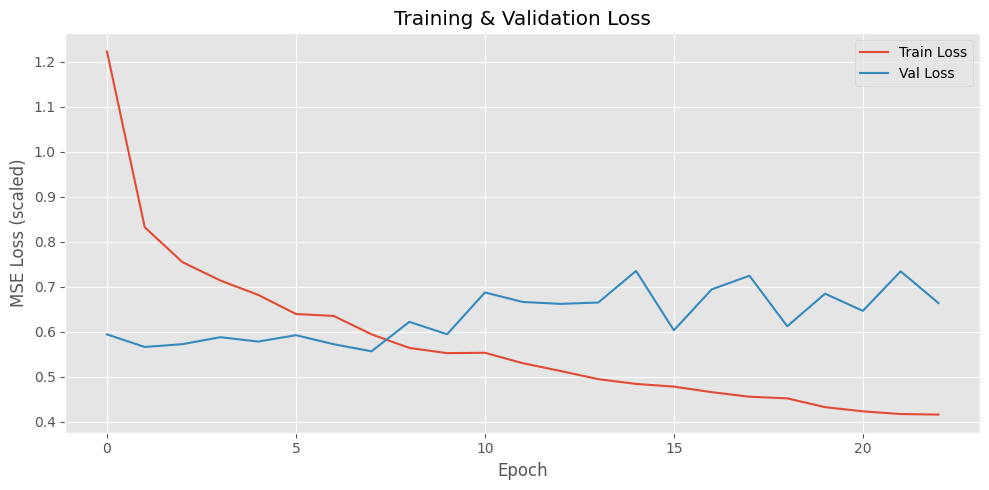

In [165]:
# === Train Model ===
train_loader = DataLoader(PM25Dataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PM25Dataset(X_val, y_val), batch_size=BATCH_SIZE)

best_model = LSTMModel(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, FORECAST_DAYS).to(device)
best_model, train_losses, val_losses = train_model(
    best_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE
)

print(f"\nTraining finished at epoch {len(train_losses)}")

# === Loss Curve ===
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=1.5)
plt.plot(val_losses, label='Val Loss', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [166]:
# === Inverse Transform: แปลง scaled predictions กลับเป็นค่าจริง ===
def inverse_pm25(scaled_values):
    """Inverse transform PM2.5 จาก RobustScaler: x_real = x_scaled * IQR + median"""
    median = robust_scaler.center_[pm25_robust_idx]
    iqr = robust_scaler.scale_[pm25_robust_idx]
    return scaled_values * iqr + median

# Predict on all sets
best_model.eval()
with torch.no_grad():
    pred_train = best_model(torch.FloatTensor(X_train).to(device)).cpu().numpy()
    pred_val   = best_model(torch.FloatTensor(X_val).to(device)).cpu().numpy()
    pred_test  = best_model(torch.FloatTensor(X_test).to(device)).cpu().numpy()

# Inverse transform ทั้ง predictions และ actual
pred_train_real = inverse_pm25(pred_train)
pred_val_real   = inverse_pm25(pred_val)
pred_test_real  = inverse_pm25(pred_test)
y_train_real    = inverse_pm25(y_train)
y_val_real      = inverse_pm25(y_val)
y_test_real     = inverse_pm25(y_test)

print("Inverse transform done.")

Inverse transform done.


In [167]:
# === 1-Step-Ahead Evaluation (Day+1 only) ===
# เปรียบเทียบกับ RF ได้ตรงๆ เพราะเป็นการทำนายวันถัดไปเหมือนกัน
print("=== 1-Step-Ahead (Day+1 only) ===")
results_1step = []
for name, y_true, y_pred in [('Train', y_train_real, pred_train_real),
                               ('Validation', y_val_real, pred_val_real),
                               ('Test', y_test_real, pred_test_real)]:
    actual = y_true[:, 0]
    predicted = y_pred[:, 0]
    r2   = r2_score(actual, predicted)
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    mbe  = np.mean(predicted - actual)
    results_1step.append({'Set': name, 'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe})
    print(f"[{name}]  R²={r2:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MBE={mbe:.4f}")

pd.DataFrame(results_1step).set_index('Set')

=== 1-Step-Ahead (Day+1 only) ===
[Train]  R²=0.8566  MSE=81.0795  RMSE=9.0044  MAE=4.6376  MBE=0.1984
[Validation]  R²=0.8270  MSE=73.7570  RMSE=8.5882  MAE=4.9138  MBE=-0.6267
[Test]  R²=0.7963  MSE=84.8979  RMSE=9.2140  MAE=4.7432  MBE=0.3619


,R2,MSE,RMSE,MAE,MBE
Set,,,,,
Train,0.856586,81.079495,9.004415,4.637611,0.198399
Validation,0.826971,73.756975,8.588188,4.913751,-0.626683
Test,0.796317,84.897850,9.214003,4.743245,0.361885


In [168]:
# === Evaluation per Forecast Horizon (Day+1 to Day+7) ===
print("=== Metrics per Horizon (Test set) ===\n")
horizon_results = []
for h in range(FORECAST_DAYS):
    actual = y_test_real[:, h]
    predicted = pred_test_real[:, h]
    r2   = r2_score(actual, predicted)
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    mbe  = np.mean(predicted - actual)
    horizon_results.append({'Horizon': f'Day+{h+1}', 'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe})
    print(f"Day+{h+1}:  R²={r2:.4f} MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MBE={mbe:.4f}")

horizon_df = pd.DataFrame(horizon_results).set_index('Horizon')
horizon_df

=== Metrics per Horizon (Test set) ===

Day+1:  R²=0.7963 MSE=84.8979  RMSE=9.2140  MAE=4.7432  MBE=0.3619
Day+2:  R²=0.6971 MSE=126.1788  RMSE=11.2329  MAE=5.8048  MBE=0.5946
Day+3:  R²=0.6144 MSE=160.4652  RMSE=12.6675  MAE=6.4871  MBE=0.6976
Day+4:  R²=0.5488 MSE=187.6799  RMSE=13.6996  MAE=6.9790  MBE=0.7238
Day+5:  R²=0.5022 MSE=206.6039  RMSE=14.3737  MAE=7.2979  MBE=0.5433
Day+6:  R²=0.4624 MSE=222.7162  RMSE=14.9237  MAE=7.5133  MBE=0.5606
Day+7:  R²=0.4346 MSE=233.6668  RMSE=15.2862  MAE=7.6709  MBE=0.6094


,R2,MSE,RMSE,MAE,MBE
Horizon,,,,,
Day+1,0.796317,84.897850,9.214003,4.743245,0.361885
Day+2,0.697148,126.178773,11.232933,5.804785,0.594600
Day+3,0.614365,160.465204,12.667486,6.487147,0.697616
Day+4,0.548763,187.679876,13.699631,6.979016,0.723837
Day+5,0.502240,206.603898,14.373722,7.297875,0.543294
Day+6,0.462388,222.716160,14.923678,7.513284,0.560643
Day+7,0.434575,233.666791,15.286163,7.670945,0.609423


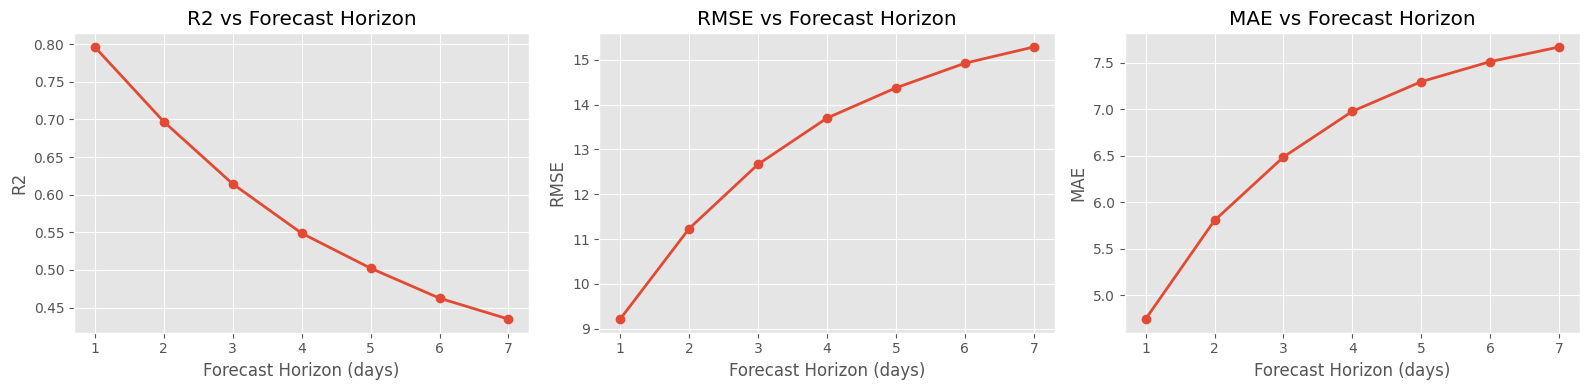

In [169]:
# === Metrics Degradation by Horizon ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    ax.plot(range(1, FORECAST_DAYS + 1), horizon_df[metric], 'o-', linewidth=2)
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Forecast Horizon')
    ax.set_xticks(range(1, FORECAST_DAYS + 1))

plt.tight_layout()
plt.show()

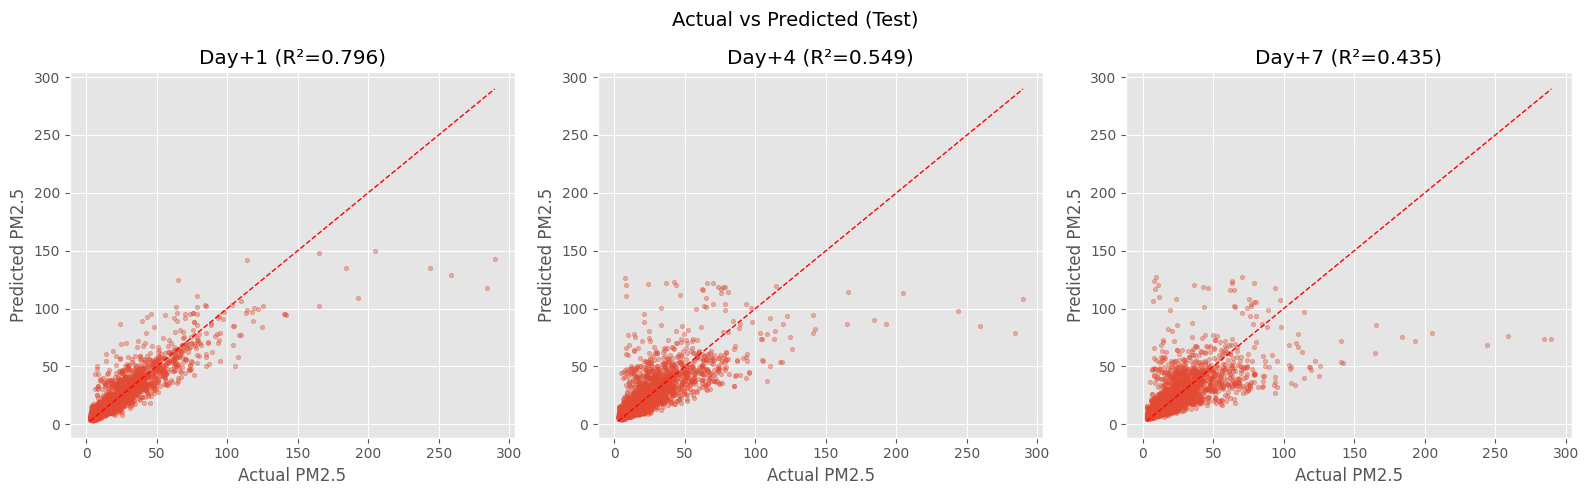

In [170]:
# === Actual vs Predicted Scatter (per horizon: Day+1, Day+4, Day+7) ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, h in zip(axes, [0, 3, 6]):
    actual = y_test_real[:, h]
    predicted = pred_test_real[:, h]
    ax.scatter(actual, predicted, alpha=0.4, s=10)
    lims = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual PM2.5')
    ax.set_ylabel('Predicted PM2.5')
    r2 = r2_score(actual, predicted)
    ax.set_title(f'Day+{h+1} (R²={r2:.3f})')

plt.suptitle('Actual vs Predicted (Test)', fontsize=14)
plt.tight_layout()
plt.show()

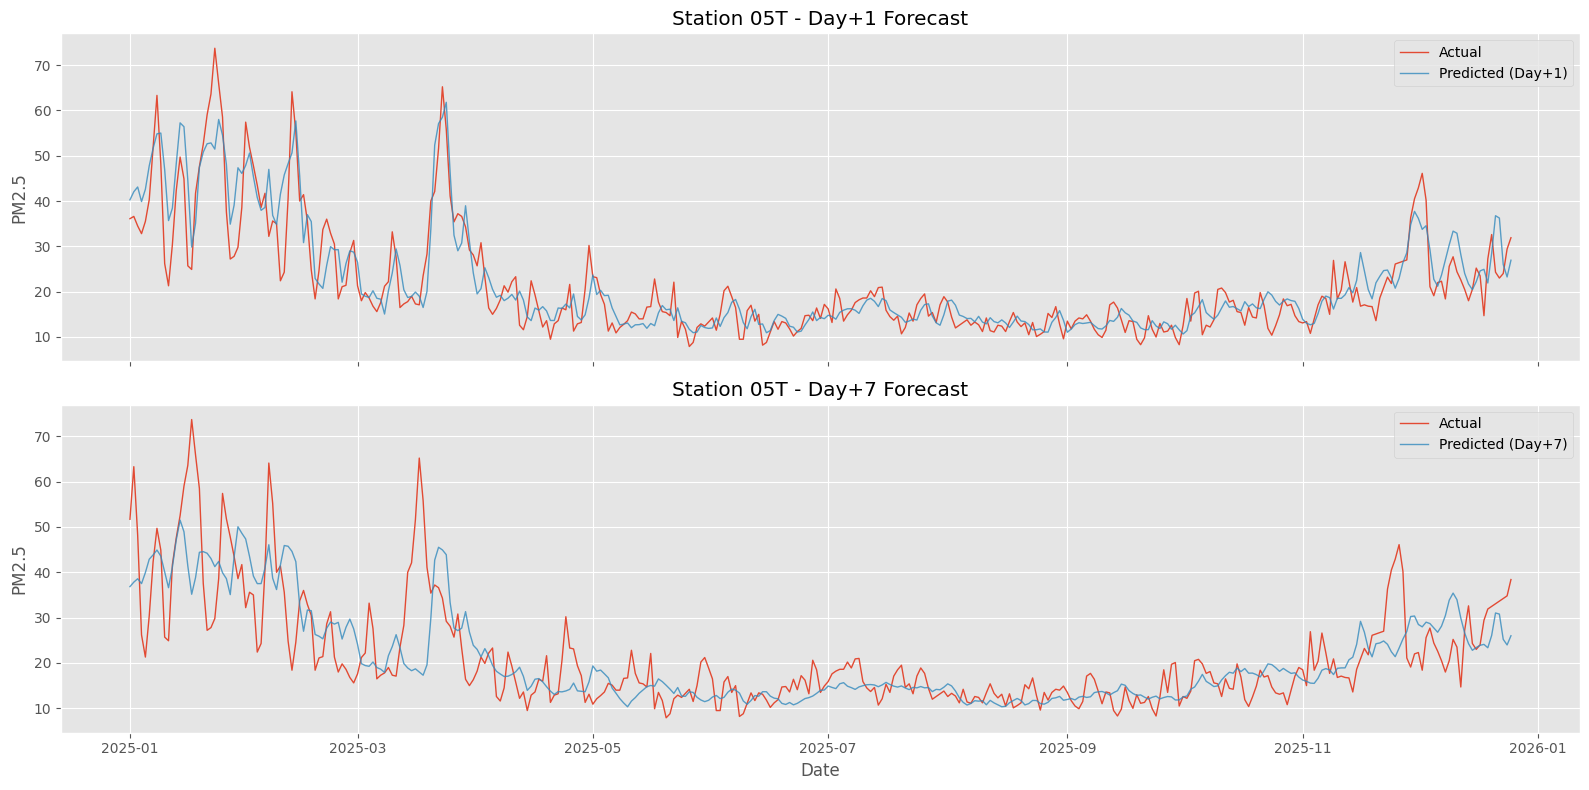

In [171]:
# === Time Series: Actual vs Predicted (sample station, Day+1 and Day+7) ===
sample_station = stations[0]
st_mask = meta_test['station'] == sample_station
st_meta = meta_test[st_mask].reset_index(drop=True)
st_actual = y_test_real[st_mask.values]
st_pred = pred_test_real[st_mask.values]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, h, label in zip(axes, [0, 6], ['Day+1', 'Day+7']):
    dates = pd.to_datetime(st_meta['target_start'])
    ax.plot(dates, st_actual[:, h], label='Actual', linewidth=1)
    ax.plot(dates, st_pred[:, h], label=f'Predicted ({label})', linewidth=1, alpha=0.8)
    ax.set_ylabel('PM2.5')
    ax.set_title(f'Station {sample_station} - {label} Forecast')
    ax.legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [172]:
# === Export Model, Scalers & Config ===
import json
import os
import joblib

export_dir = 'LSTM_export'
os.makedirs(export_dir, exist_ok=True)

# Save model weights
torch.save(best_model.state_dict(), os.path.join(export_dir, 'lstm_model.pth'))

# Save scalers
joblib.dump(robust_scaler, os.path.join(export_dir, 'robust_scaler.joblib'))
joblib.dump(standard_scaler, os.path.join(export_dir, 'standard_scaler.joblib'))

# Save config
lstm_config = {
    'window_size': WINDOW_SIZE,
    'forecast_days': FORECAST_DAYS,
    'feature_cols': feature_cols,
    'target_col': target_col,
    'pm25_idx': pm25_idx,
    'pm25_robust_idx': pm25_robust_idx,
    'input_size': input_size,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'robust_cols': robust_cols,
    'standard_cols': standard_cols,
    'passthrough_cols': passthrough_cols,
}
with open(os.path.join(export_dir, 'model_config.json'), 'w') as f:
    json.dump(lstm_config, f, indent=2)

print(f"Model saved to {export_dir}/lstm_model.pth")
print(f"Scalers saved to {export_dir}/")
print(f"Config saved to {export_dir}/model_config.json")

Model saved to LSTM_export/lstm_model.pth
Scalers saved to LSTM_export/
Config saved to LSTM_export/model_config.json
